In [ ]:

import numpy as np
import matplotlib.pyplot as plt 

from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.colors as mcolors 
import scipy

import os
import pickle

# auto reload modules 
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('C:/Users/sebas/Github/icewave/')

import icewave.tools.matlab_colormaps as matcmaps
import icewave.sebastien.set_graphs as set_graphs
import icewave.sebastien.theory.module_bilayer_viscous_dimensionless as theory


# PARULA COLORMAP 
parula_map = matcmaps.parula()

plt.rc('text', usetex=True)
plt.rc('font', family='serif', serif='Computer Modern')

# Set global parameters
global g
g = 9.81

global main_path
global fig_folder

def savefolder():
    main_path = 'C:/Users/sebas/OneDrive/Bureau/These PMMH/waves_attenuation/'
    fig_folder = f'{main_path}velocity_dimensionless/'
    if not os.path.isdir(fig_folder):
        os.mkdir(fig_folder)


## Function section

In [4]:
def p_dimensionless(kappa,coeffs,dimensionless,z,fluid_idx):
    [A_1,B_1,C_1,D_1,A_2,C_2] = coeffs
    gamma, delta_1, delta_2, r = dimensionless    
    if fluid_idx == 1:
        p = C_1*np.exp(kappa*z) + D_1*np.exp(-kappa*z)
    else:
        p = C_2*np.exp(kappa*z) 
    return p

def vorticity_dimensionless(kappa,coeffs,dimensionless,z,fluid_idx):
    [A_1,B_1,C_1,D_1,A_2,C_2] = coeffs
    gamma, delta_1, delta_2, r = dimensionless

    A_1_star = A_1/(delta_1**2)
    B_1_star = B_1/(delta_1**2)
    A_2_star = A_2/(delta_2**2)

    m_1 = np.sqrt(kappa**2 - 1j*1/delta_1**2)
    m_2 = np.sqrt(kappa**2 - 1j*1/delta_2**2)

    if fluid_idx == 1:
        vort = A_1_star*np.exp(m_1*z) + B_1_star*np.exp(-m_1*z)
    else:
        vort = A_2_star*np.exp(m_2*z)
    return vort


def u_dimensionless(kappa,coeffs,dimensionless,z,fluid_idx):
    
    [A_1,B_1,C_1,D_1,A_2,C_2] = coeffs
    gamma, delta_1, delta_2, r = dimensionless
    
    m_1 = np.sqrt(kappa**2 - 1j*1/delta_1**2)
    m_2 = np.sqrt(kappa**2 - 1j*1/delta_2**2)
    
    if fluid_idx == 1:
        pressure_term = kappa*(C_1*np.exp(kappa*z) + D_1*np.exp(-kappa*z))
        vort_term = 1j*m_1*(A_1*np.exp(m_1*z) - B_1*np.exp(-m_1*z))
        
        u = pressure_term + vort_term
    
    else:
        pressure_term = r*kappa*C_2*np.exp(kappa*z) 
        vort_term = 1j*m_2*A_2*np.exp(m_2*z)
        
        u = pressure_term + vort_term
        
    return u

def w_dimensionless(kappa,coeffs,dimensionless,z,fluid_idx):

    [A_1,B_1,C_1,D_1,A_2,C_2] = coeffs
    gamma, delta_1, delta_2, r = dimensionless    

    m_1 = np.sqrt(kappa**2 - 1j*1/delta_1**2)
    m_2 = np.sqrt(kappa**2 - 1j*1/delta_2**2)
    
    if fluid_idx == 1:
        pressure_term = -1j*kappa*(C_1*np.exp(kappa*z) - D_1*np.exp(-kappa*z))
        vort_term = kappa*(A_1*np.exp(m_1*z) + B_1*np.exp(-m_1*z))

        w = pressure_term + vort_term
        
    else:
        
        pressure_term = -1j*kappa*r*C_2*np.exp(kappa*z) 
        vort_term = kappa*A_2*np.exp(m_2*z)
        
        w = pressure_term + vort_term
        
    return w
    

## Get coefficients

In [11]:
# create dictionnary 
my_dict = {}
my_dict['f'] = np.linspace(1,10,100)

# set parameters 
h = 0.01 # in meters
rho_1 = 1e3
rho_2 = 1e3
nu_1 = 1e-6
nu_2 = 1e-6

my_dict['params'] = np.array([(f,h,rho_1,rho_2,nu_1,nu_2) for f in f_array])
my_dict['dimensionless'] = np.array([theory.dim_numbers(params) for params 
                                     in my_dict['params']])

my_dict['omega'] = 2*np.pi*my_dict['f']
my_dict['k0'] = my_dict['omega']**2/g
my_dict['kappa'] = np.zeros(my_dict['f'].shape,dtype = 'complex')
my_dict['coeffs'] = []
    
# get complex wavevector 
initial_guess = [1 , 0.1] # initial guess for [Re(kappa), Im(kappa)]
for i,dimensionless in enumerate(my_dict['dimensionless']):
    
    solution = scipy.optimize.fsolve(theory.func_real_imag,initial_guess,(dimensionless,))
    root = solution[0] + 1j*solution[1]
    print(f'Root of det(M) = {root}')
    initial_guess = solution
    my_dict['kappa'][i] = root
    my_dict['coeffs'].append(theory.get_coeffs(root, dimensionless))

my_dict['coeffs'] = np.array(my_dict['coeffs'])

Root of det(M) = (1.0000000114654424+1.0298365462247803e-05j)
Root of det(M) = (1.0000000169120051+1.3367961186719309e-05j)
Root of det(M) = (1.0000000241718736+1.699337922120683e-05j)
Root of det(M) = (1.0000000336335193+2.1220676743542265e-05j)
Root of det(M) = (1.000000045728248+2.6095859652483445e-05j)
Root of det(M) = (1.0000000609311777+3.166488095595152e-05j)
Root of det(M) = (1.0000000797617683+3.797363820968689e-05j)
Root of det(M) = (1.0000001027841492+4.506797267649471e-05j)
Root of det(M) = (1.0000001306073028+5.29936668919417e-05j)
Root of det(M) = (1.0000001638851264+6.179644331359229e-05j)
Root of det(M) = (1.0000002033163506+7.15219627116481e-05j)
Root of det(M) = (1.0000002496443225+8.221582256080668e-05j)
Root of det(M) = (1.0000003036566618+9.392355551223394e-05j)
Root of det(M) = (1.0000003661847945+0.00010669062812347926j)
Root of det(M) = (1.000000438103362+0.00012056243910567932j)
Root of det(M) = (1.000000520329516+0.00013558431826432536j)
Root of det(M) = (1.00

## Compute vorticity field

In [29]:
my_dict['z1'] = np.linspace(0,h,100) # in meter
my_dict['z2'] = np.linspace(h,0.1,200) # in meter

my_dict['vort1'] = np.zeros((len(my_dict['z1']),len(my_dict['f'])),dtype = 'complex')
my_dict['vort2'] = np.zeros((len(my_dict['z2']),len(my_dict['f'])),dtype = 'complex')
                             
for i in range(len(my_dict['f'])): 
    z_star_1 = my_dict['z1']*my_dict['k0'][i]

    kappa = my_dict['kappa'][i]
    coeffs  = my_dict['coeffs'][i]
    dimensionless = my_dict['dimensionless'][i]
    my_dict['vort1'][:,i] = vorticity_dimensionless(kappa,coeffs,
                                        dimensionless,my_dict['z1'],1)

    my_dict['vort2'][:,i] = vorticity_dimensionless(kappa,coeffs,
                                    dimensionless,my_dict['z2'],1)


1.9090909090909092
(1.0000002033163506+7.15219627116481e-05j)


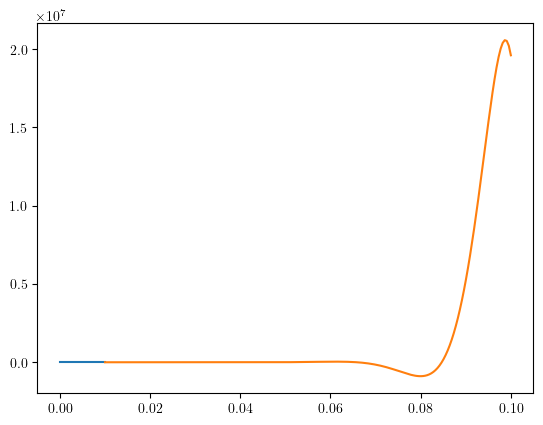

In [30]:

i = 10
print(my_dict['f'][i])
print(my_dict['kappa'][i])
fig, ax = plt.subplots()

ax.plot(my_dict['z1'],np.real(my_dict['vort1'][:,i]))
ax.plot(my_dict['z2'],np.real(my_dict['vort2'][:,i]))


### Plot mean vorticity for each frequency 

In [31]:
my_dict['vort2'].shape

(200, 100)

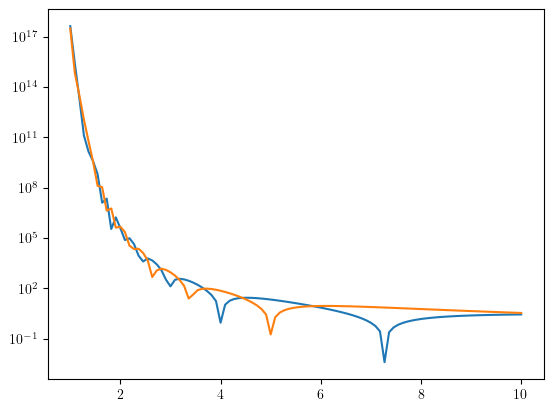

In [38]:
mean_vort = np.mean(my_dict['vort2'],axis = 0)

fig, ax = plt.subplots()
ax.plot(my_dict['f'],abs(np.real(mean_vort)))
ax.plot(my_dict['f'],abs(np.imag(mean_vort)))

ax.set_yscale('log')

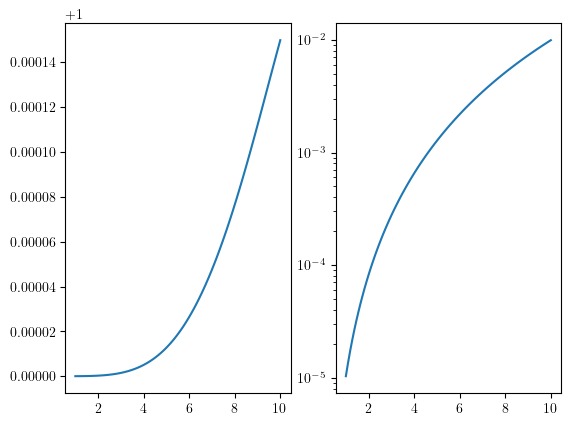

In [40]:
fig, axs = plt.subplots(ncols = 2)
axs[0].plot(my_dict['f'],np.real(my_dict['kappa']))
axs[1].plot(my_dict['f'],np.imag(my_dict['kappa']))
axs[1].set_yscale('log')

In [15]:
my_dict['vort1']

array([[-2.00000002-2.05967309e-05j, -2.00000003-2.67359224e-05j,
        -2.00000005-3.39867585e-05j, ..., -2.00028611-1.88562444e-02j,
        -2.00029295-1.93759436e-02j, -2.00029972-1.99049076e-02j],
       [-2.08891834+9.29727968e-02j, -2.07805093+8.11509370e-02j,
        -2.06922856+7.16458158e-02j, ..., -2.0032095 -1.59903129e-02j,
        -2.00317704-1.65502522e-02j, -2.00314542-1.71185535e-02j],
       [-2.17746593+1.94235003e-01j, -2.15585281+1.68664597e-01j,
        -2.13828429+1.48287901e-01j, ..., -2.00613297-1.31160037e-02j,
        -2.00606122-1.37164115e-02j, -2.00599121-1.43242706e-02j],
       ...,
       [57.8782697 -1.38045095e+02j, 70.50502385-5.31279430e+01j,
        56.16232738-1.23978120e+01j, ..., -2.28236835+2.99951444e-01j,
        -2.27864512+2.94391338e-01j, -2.27500516+2.88951460e-01j],
       [54.03275717-1.46873572e+02j, 71.10004666-5.80630096e+01j,
        57.66196669-1.48398308e+01j, ..., -2.28523903+3.03686967e-01j,
        -2.28147912+2.98062157e-01j

In [7]:
params_array

array([[1.00000000e+00, 1.00000000e-02, 1.00000000e+03, 1.00000000e+03,
        1.00000000e-06, 1.00000000e-06],
       [1.09090909e+00, 1.00000000e-02, 1.00000000e+03, 1.00000000e+03,
        1.00000000e-06, 1.00000000e-06],
       [1.18181818e+00, 1.00000000e-02, 1.00000000e+03, 1.00000000e+03,
        1.00000000e-06, 1.00000000e-06],
       [1.27272727e+00, 1.00000000e-02, 1.00000000e+03, 1.00000000e+03,
        1.00000000e-06, 1.00000000e-06],
       [1.36363636e+00, 1.00000000e-02, 1.00000000e+03, 1.00000000e+03,
        1.00000000e-06, 1.00000000e-06],
       [1.45454545e+00, 1.00000000e-02, 1.00000000e+03, 1.00000000e+03,
        1.00000000e-06, 1.00000000e-06],
       [1.54545455e+00, 1.00000000e-02, 1.00000000e+03, 1.00000000e+03,
        1.00000000e-06, 1.00000000e-06],
       [1.63636364e+00, 1.00000000e-02, 1.00000000e+03, 1.00000000e+03,
        1.00000000e-06, 1.00000000e-06],
       [1.72727273e+00, 1.00000000e-02, 1.00000000e+03, 1.00000000e+03,
        1.00000000e-06, 